In [160]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [161]:
spotify = pd.read_csv('spotify_tracks.csv')

In [162]:
df = spotify.copy()

In [163]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62317 entries, 0 to 62316
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          62317 non-null  object 
 1   track_name        62317 non-null  object 
 2   artist_name       62317 non-null  object 
 3   year              62317 non-null  int64  
 4   popularity        62317 non-null  int64  
 5   artwork_url       62317 non-null  object 
 6   album_name        62317 non-null  object 
 7   acousticness      62317 non-null  float64
 8   danceability      62317 non-null  float64
 9   duration_ms       62317 non-null  float64
 10  energy            62317 non-null  float64
 11  instrumentalness  62317 non-null  float64
 12  key               62317 non-null  float64
 13  liveness          62317 non-null  float64
 14  loudness          62317 non-null  float64
 15  mode              62317 non-null  float64
 16  speechiness       62317 non-null  float6

In [164]:
spotify.isnull().sum().sum()

np.int64(0)

In [165]:
spotify.shape

(62317, 22)

In [166]:
spotify.dropna(inplace=True)

In [167]:
spotify.shape

(62317, 22)

In [168]:
spotify.head(5)

,track_id,track_name,artist_name,year,popularity,artwork_url,album_name,acousticness,danceability,duration_ms,...,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,track_url,language
0,2r0ROhr7pRN4MXDMT1fEmd,"Leo Das Entry (From ""Leo"")",Anirudh Ravichander,2024,59,https://i.scdn.co/image/ab67616d0000b273ce9c65...,"Leo Das Entry (From ""Leo"")",0.0241,0.753,97297.0,...,8.0,0.1000,-5.994,0.0,0.1030,110.997,4.0,0.459,https://open.spotify.com/track/2r0ROhr7pRN4MXD...,Tamil
1,4I38e6Dg52a2o2a8i5Q5PW,AAO KILLELLE,"Anirudh Ravichander, Pravin Mani, Vaishali Sri...",2024,47,https://i.scdn.co/image/ab67616d0000b273be1b03...,AAO KILLELLE,0.0851,0.780,207369.0,...,10.0,0.0951,-5.674,0.0,0.0952,164.995,3.0,0.821,https://open.spotify.com/track/4I38e6Dg52a2o2a...,Tamil
2,59NoiRhnom3lTeRFaBzOev,Mayakiriye Sirikiriye - Orchestral EDM,"Anirudh Ravichander, Anivee, Alvin Bruno",2024,35,https://i.scdn.co/image/ab67616d0000b27334a1dd...,Mayakiriye Sirikiriye (Orchestral EDM),0.0311,0.457,82551.0,...,2.0,0.0831,-8.937,0.0,0.1530,169.996,4.0,0.598,https://open.spotify.com/track/59NoiRhnom3lTeR...,Tamil
3,5uUqRQd385pvLxC8JX3tXn,Scene Ah Scene Ah - Experimental EDM Mix,"Anirudh Ravichander, Bharath Sankar, Kabilan, ...",2024,24,https://i.scdn.co/image/ab67616d0000b27332e623...,Scene Ah Scene Ah (Experimental EDM Mix),0.2270,0.718,115831.0,...,7.0,0.1240,-11.104,1.0,0.4450,169.996,4.0,0.362,https://open.spotify.com/track/5uUqRQd385pvLxC...,Tamil
4,1KaBRg2xgNeCljmyxBH1mo,Gundellonaa X I Am A Disco Dancer - Mashup,"Anirudh Ravichander, Benny Dayal, Leon James, ...",2024,22,https://i.scdn.co/image/ab67616d0000b2735a59b6...,Gundellonaa X I Am a Disco Dancer (Mashup),0.0153,0.689,129621.0,...,7.0,0.3450,-9.637,1.0,0.1580,128.961,4.0,0.593,https://open.spotify.com/track/1KaBRg2xgNeCljm...,Tamil


In [169]:
spotify.describe()

,year,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
count,62317.000000,62317.000000,62317.000000,62317.000000,6.231700e+04,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000
mean,2014.425935,15.358361,0.362292,0.596807,2.425270e+05,0.602496,0.146215,5.101658,0.194143,-65.103433,0.586052,0.087722,117.931247,3.857086,0.495226
std,9.645113,18.626908,0.314609,0.186209,1.129999e+05,0.246144,0.307804,3.553469,0.172030,2369.051478,0.493682,0.115150,28.509459,0.502660,0.264787
min,1971.000000,0.000000,-1.000000,-1.000000,5.000000e+03,-1.000000,-1.000000,-1.000000,-1.000000,-100000.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2011.000000,0.000000,0.067100,0.497000,1.921600e+05,0.440000,0.000000,2.000000,0.093200,-10.727000,0.000000,0.036700,95.942000,4.000000,0.292000
50%,2017.000000,7.000000,0.286000,0.631000,2.362670e+05,0.639000,0.000025,5.000000,0.125000,-7.506000,1.000000,0.048900,117.991000,4.000000,0.507000
75%,2022.000000,26.000000,0.632000,0.730000,2.862400e+05,0.803000,0.015200,8.000000,0.243000,-5.456000,1.000000,0.089100,135.081000,4.000000,0.710000
max,2024.000000,93.000000,0.996000,0.986000,4.581483e+06,1.000000,0.999000,11.000000,0.998000,1.233000,1.000000,0.959000,239.970000,5.000000,0.995000


Popularity:-

In [170]:
spotify['popularity'].describe()

,popularity
count,62317.000000
mean,15.358361
std,18.626908
min,0.000000
25%,0.000000
50%,7.000000
75%,26.000000
max,93.000000


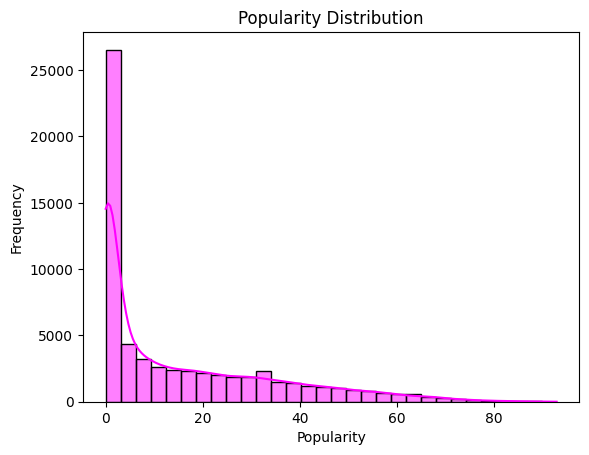

In [171]:
sns.histplot(spotify['popularity'], kde=True, bins=30, color='magenta')
plt.title('Popularity Distribution')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.show()

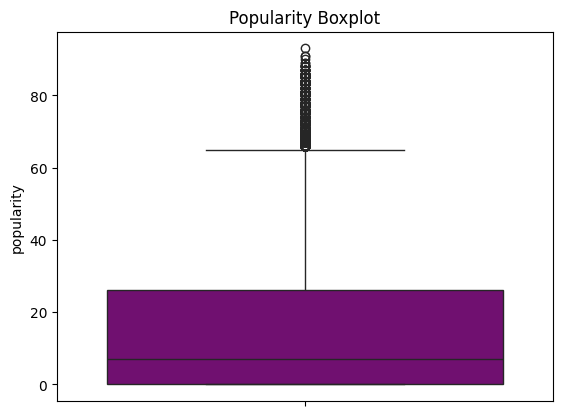

In [172]:
sns.boxplot(y=spotify['popularity'], color='purple')
plt.title('Popularity Boxplot')
plt.show()

In [173]:
print("Skewness:", spotify['popularity'].skew())
print("Kurtosis:", spotify['popularity'].kurt())


Skewness: 1.2312041369148423
Kurtosis: 0.6617649764728428


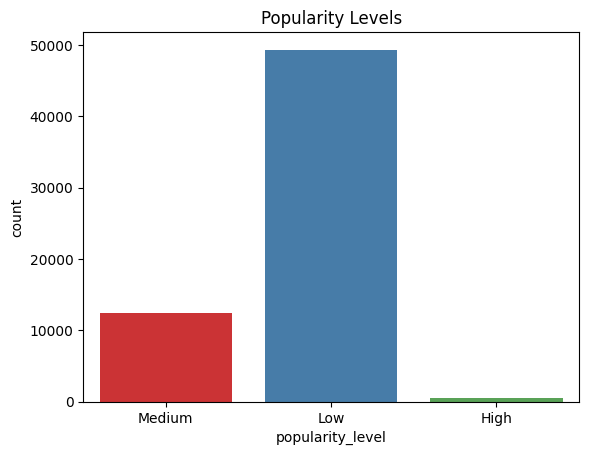

In [174]:
def popularity_category(x):
    if x <= 30:
        return 'Low'
    elif x <= 70:
        return 'Medium'
    else:
        return 'High'

spotify['popularity_level'] = spotify['popularity'].apply(popularity_category)
sns.countplot(x='popularity_level', data=spotify, palette='Set1')
plt.title('Popularity Levels')
plt.show()

In [175]:
spotify[spotify['popularity'] == 0].shape

(17703, 23)

Acousticness:-

In [176]:
spotify['acousticness'].describe()

,acousticness
count,62317.000000
mean,0.362292
std,0.314609
min,-1.000000
25%,0.067100
50%,0.286000
75%,0.632000
max,0.996000


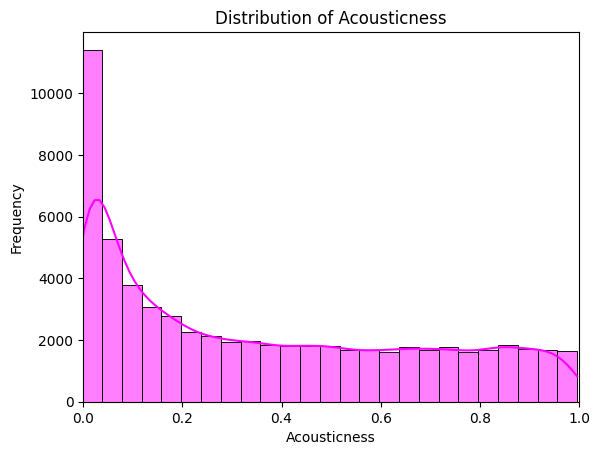

In [177]:
sns.histplot(spotify['acousticness'], kde=True, bins=50,color="magenta")
plt.title('Distribution of Acousticness')
plt.xlabel('Acousticness')
plt.ylabel('Frequency')
plt.xlim(0, 1)
plt.show()

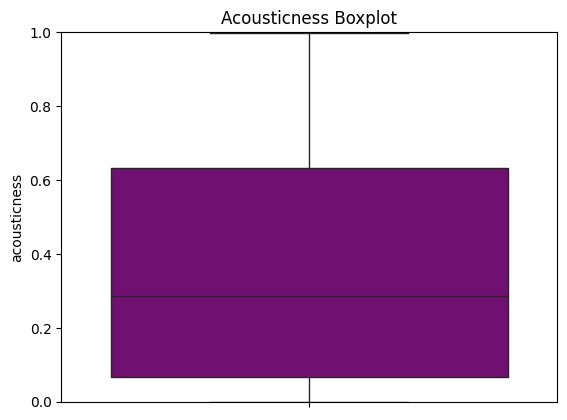

In [178]:
sns.boxplot(data=spotify, y='acousticness', color='purple')
plt.title('Acousticness Boxplot')
plt.ylim(0,1)
plt.show()

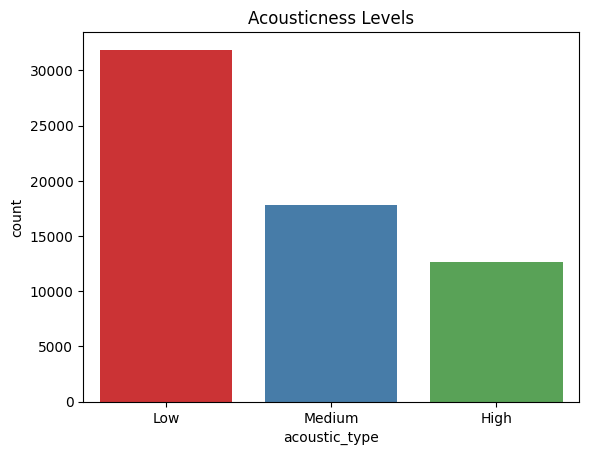

In [179]:
def acoustic_type(val):
    if val < 0.3:
        return "Low"
    elif val < 0.7:
        return "Medium"
    else:
        return "High"

spotify['acoustic_type'] = spotify['acousticness'].apply(acoustic_type)
sns.countplot(x='acoustic_type', data=spotify, palette='Set1')
plt.title('Acousticness Levels')
plt.show()

Danceability:-

In [180]:
spotify['danceability'].describe()

,danceability
count,62317.000000
mean,0.596807
std,0.186209
min,-1.000000
25%,0.497000
50%,0.631000
75%,0.730000
max,0.986000


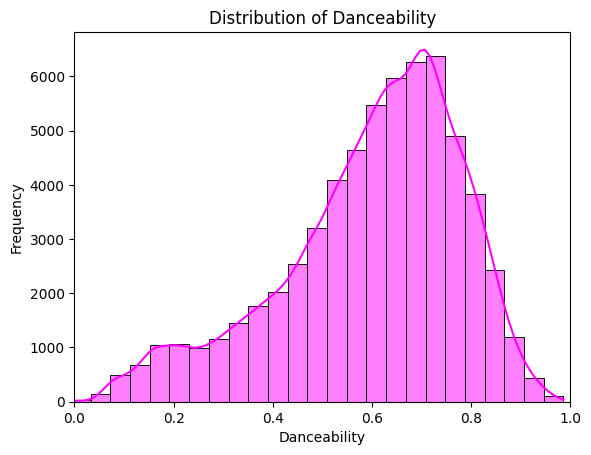

In [181]:
sns.histplot(data=spotify, x='danceability', kde=True, bins=50, color='magenta')
plt.title('Distribution of Danceability')
plt.xlabel('Danceability')
plt.ylabel('Frequency')
plt.xlim(0,1)
plt.show()

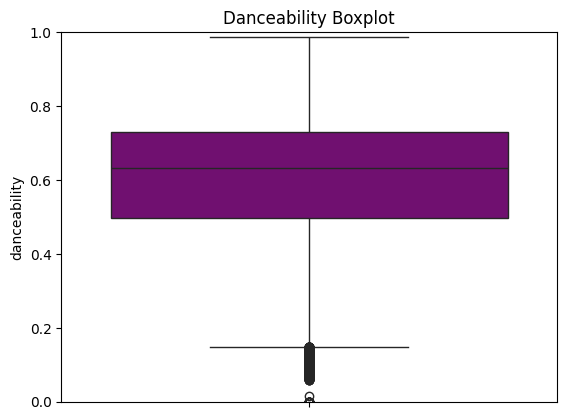

In [182]:
sns.boxplot(data=spotify, y='danceability', color='purple')
plt.title('Danceability Boxplot')
plt.ylim(0,1)
plt.show()

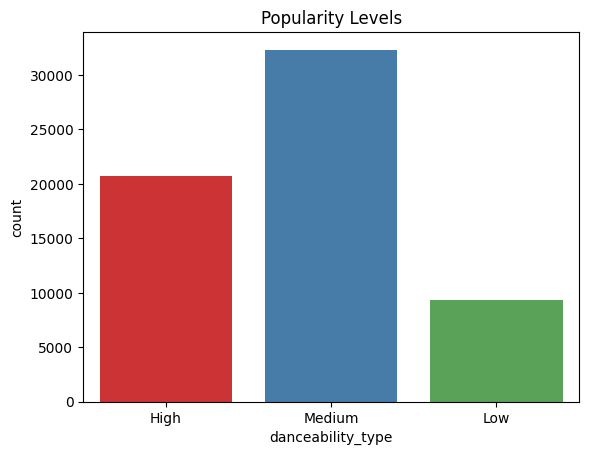

In [183]:
def dance_type(val):
    if val < 0.4:
        return "Low"
    elif val < 0.7:
        return "Medium"
    else:
        return "High"

spotify['danceability_type'] = spotify['danceability'].apply(dance_type)
sns.countplot(x='danceability_type', data=spotify, palette='Set1')
plt.title('Popularity Levels')
plt.show()


Duration_ms:-

In [184]:
spotify['duration_min'] = spotify['duration_ms'] / 60000

In [185]:
spotify['duration_min'].describe()

,duration_min
count,62317.000000
mean,4.042117
std,1.883332
min,0.083333
25%,3.202667
50%,3.937783
75%,4.770667
max,76.358050


In [186]:
spotify[spotify['duration_min'] == spotify['duration_min'].min()]

,track_id,track_name,artist_name,year,popularity,artwork_url,album_name,acousticness,danceability,duration_ms,...,speechiness,tempo,time_signature,valence,track_url,language,popularity_level,acoustic_type,danceability_type,duration_min
48257,5nvjbf2VisDwoPyu3uw5Ru,Silly Stroller,Blake Neely,2024,0,https://i.scdn.co/image/ab67616d0000b2739b32cf...,Sneaky Comedy Bumpers,-1.0,-1.0,5000.0,...,-1.0,-1.0,-1.0,-1.0,https://open.spotify.com/track/5nvjbf2VisDwoPy...,English,Low,Low,Low,0.083333
48263,1eayjmERbxJCgKzv7cqtks,Human Locomotive,Blake Neely,2024,0,https://i.scdn.co/image/ab67616d0000b2734c3e35...,Funky Bumpers,-1.0,-1.0,5000.0,...,-1.0,-1.0,-1.0,-1.0,https://open.spotify.com/track/1eayjmERbxJCgKz...,English,Low,Low,Low,0.083333


In [187]:
spotify[spotify['duration_min'] == spotify['duration_min'].max()]

,track_id,track_name,artist_name,year,popularity,artwork_url,album_name,acousticness,danceability,duration_ms,...,speechiness,tempo,time_signature,valence,track_url,language,popularity_level,acoustic_type,danceability_type,duration_min
55978,1FSYDJAlyHAabWhiGgYfDq,52 Non Stop Dilbar Dilbar Remix(Remix By Kedro...,"Arya Acharya, Aastha Gill, Amaal Mallik, Ankit...",2018,52,https://i.scdn.co/image/ab67616d0000b273a48f9e...,52 Non Stop Dilbar Dilbar Remix,0.0593,0.521,4581483.0,...,0.0794,106.001,4.0,0.48,https://open.spotify.com/track/1FSYDJAlyHAabWh...,Hindi,Medium,Low,Medium,76.35805


In [188]:
spotify[spotify['duration_min'] == spotify['duration_min'].max()]

,track_id,track_name,artist_name,year,popularity,artwork_url,album_name,acousticness,danceability,duration_ms,...,speechiness,tempo,time_signature,valence,track_url,language,popularity_level,acoustic_type,danceability_type,duration_min
55978,1FSYDJAlyHAabWhiGgYfDq,52 Non Stop Dilbar Dilbar Remix(Remix By Kedro...,"Arya Acharya, Aastha Gill, Amaal Mallik, Ankit...",2018,52,https://i.scdn.co/image/ab67616d0000b273a48f9e...,52 Non Stop Dilbar Dilbar Remix,0.0593,0.521,4581483.0,...,0.0794,106.001,4.0,0.48,https://open.spotify.com/track/1FSYDJAlyHAabWh...,Hindi,Medium,Low,Medium,76.35805


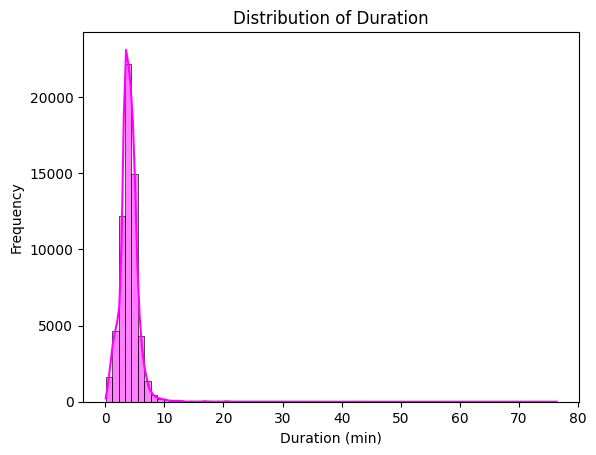

In [189]:
sns.histplot(data=spotify, x='duration_min', kde=True, bins=70, color='magenta')
plt.title('Distribution of Duration')
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.show()

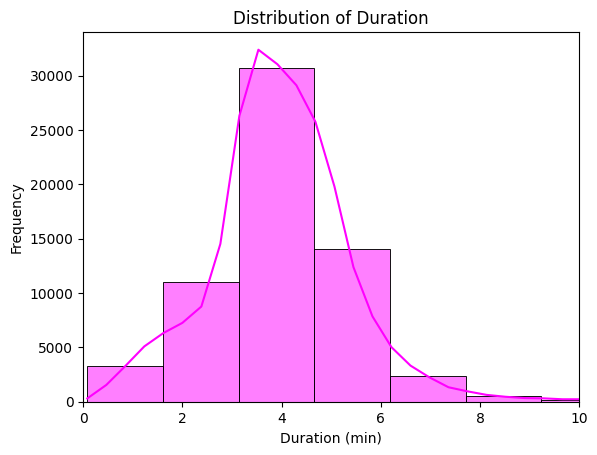

In [190]:
sns.histplot(data=spotify, x='duration_min', kde=True, bins=50, color='magenta')
plt.title('Distribution of Duration')
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.xlim(0,10)
plt.show()

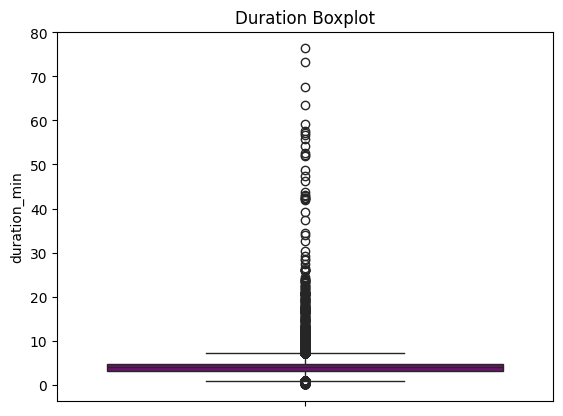

In [191]:
sns.boxplot(data=spotify, y='duration_min', color='purple')
plt.title('Duration Boxplot')
plt.show()

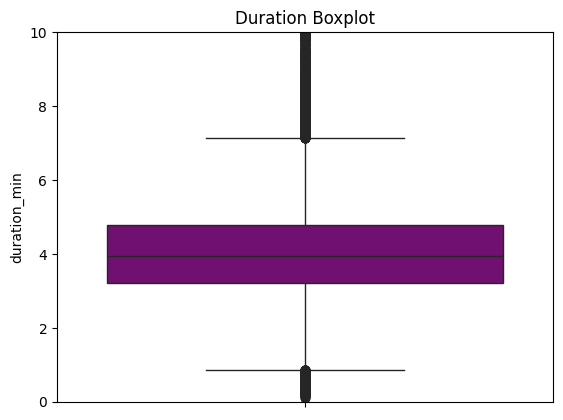

In [192]:
sns.boxplot(data=spotify, y='duration_min', color='purple')
plt.title('Duration Boxplot')
plt.ylim(0,10)
plt.show()

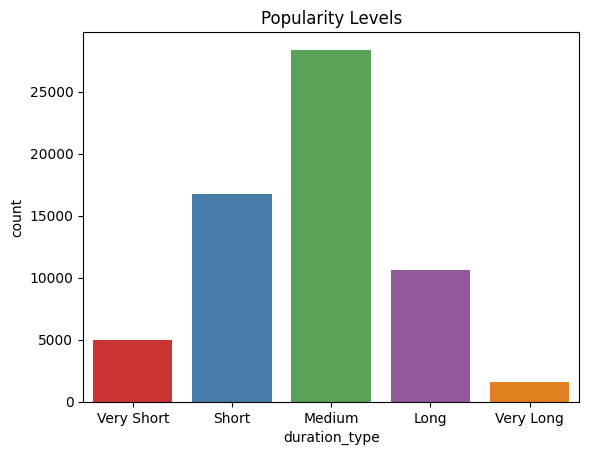

In [193]:
def duration_type(val):
    if val < 2:
        return "Very Short"
    elif val < 3.5:
        return "Short"
    elif val < 5:
        return "Medium"
    elif val < 7:
        return "Long"
    else:
        return "Very Long"

spotify['duration_type'] = spotify['duration_min'].apply(duration_type)
sns.countplot(x='duration_type', data=spotify, palette='Set1')
plt.title('Popularity Levels')
plt.show()

Energy:-

In [194]:
spotify['energy'].describe()

,energy
count,62317.000000
mean,0.602496
std,0.246144
min,-1.000000
25%,0.440000
50%,0.639000
75%,0.803000
max,1.000000


In [195]:
spotify[spotify['energy']<=0].shape

(36, 27)

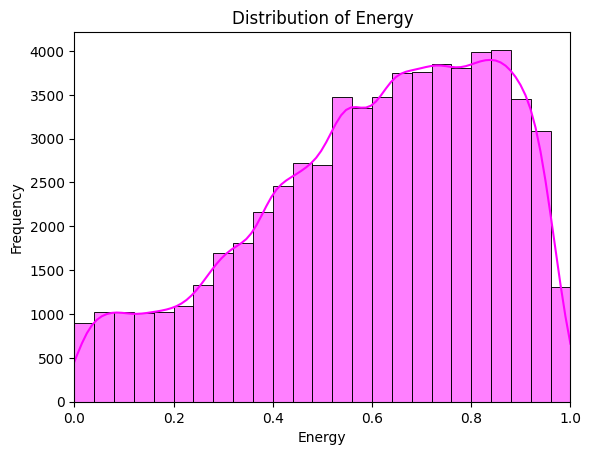

In [196]:
sns.histplot(data=spotify, x='energy', kde=True, bins=50, color='magenta')
plt.title('Distribution of Energy')
plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.xlim(0,1)
plt.show()

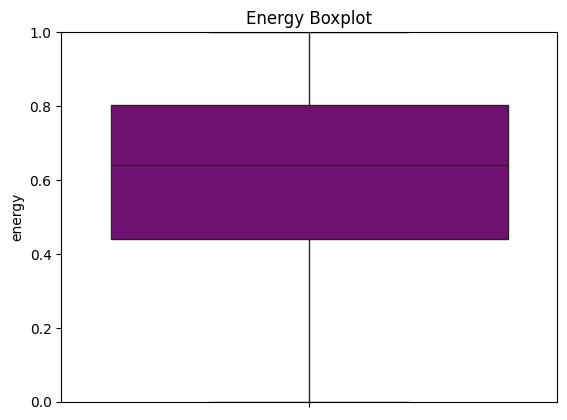

In [197]:
sns.boxplot(data=spotify, y='energy', color='purple')
plt.title('Energy Boxplot')
plt.ylim(0,1)
plt.show()

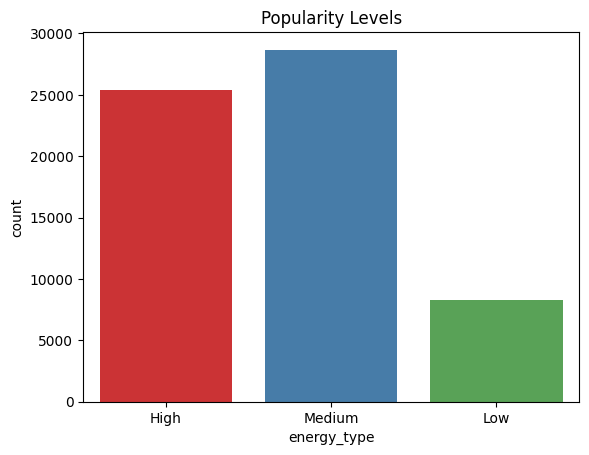

In [198]:
def energy_type(val):
    if val < 0.3:
        return "Low"
    elif val < 0.7:
        return "Medium"
    else:
        return "High"
spotify['energy_type'] = spotify['energy'].apply(energy_type)
sns.countplot(x='energy_type', data=spotify, palette='Set1')
plt.title('Popularity Levels')
plt.show()

Instrumentalness:-

In [199]:
spotify['instrumentalness'].describe()

,instrumentalness
count,62317.000000
mean,0.146215
std,0.307804
min,-1.000000
25%,0.000000
50%,0.000025
75%,0.015200
max,0.999000


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

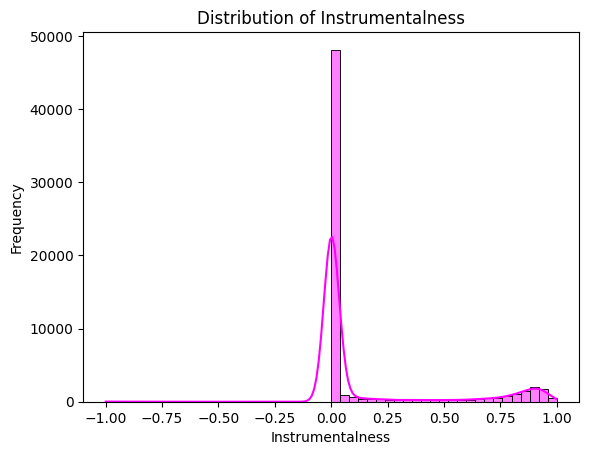

In [200]:
sns.histplot(data=spotify, x='instrumentalness', kde=True, bins=50, color='magenta')
plt.title('Distribution of Instrumentalness')
plt.xlabel('Instrumentalness')
plt.ylabel('Frequency')
plt

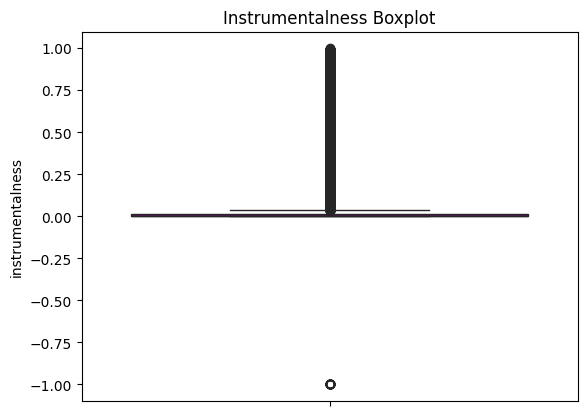

In [201]:
sns.boxplot(data=spotify, y='instrumentalness', color='purple')
plt.title('Instrumentalness Boxplot')
plt.show()

In [202]:
def instrumental_type(val):
    if val < 0.2:
        return "Vocal"
    elif val < 0.5:
        return "Mixed"
    else:
        return "Instrumental"

spotify['instrumental_type'] = spotify['instrumentalness'].apply(instrumental_type)

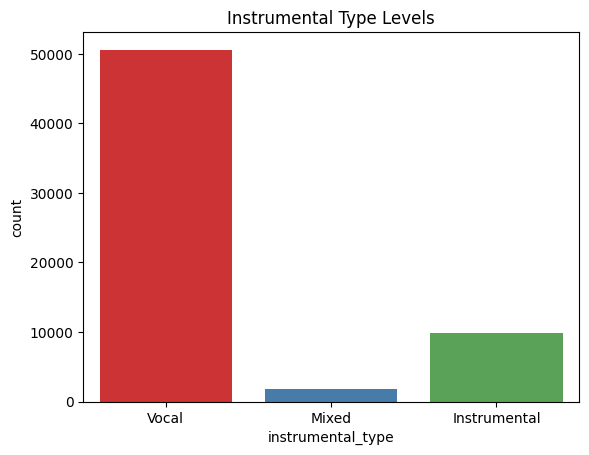

In [203]:
sns.countplot(x='instrumental_type', data=spotify, palette='Set1')
plt.title('Instrumental Type Levels')
plt.show()

Key:-

In [204]:
key_map = {
    0: 'C', 1: 'C#/Db', 2: 'D', 3: 'D#/Eb',
    4: 'E', 5: 'F', 6: 'F#/Gb', 7: 'G',
    8: 'G#/Ab', 9: 'A', 10: 'A#/Bb', 11: 'B'
}

spotify['key_note'] = spotify['key'].map(key_map)
spotify['key_note'].value_counts()

,count
key_note,
C,8113
G,6959
D,6839
F,6419
A,5873
C#/Db,5750
E,4879
B,4474
A#/Bb,3928


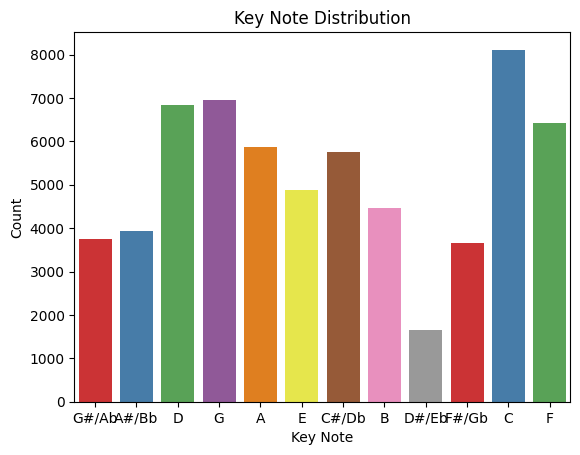

In [205]:
sns.countplot(x='key_note', data=spotify, palette='Set1')
plt.title('Key Note Distribution')
plt.xlabel('Key Note')
plt.ylabel('Count')
plt.show()

Liveness:-

In [206]:
spotify['liveness'].describe()

,liveness
count,62317.000000
mean,0.194143
std,0.172030
min,-1.000000
25%,0.093200
50%,0.125000
75%,0.243000
max,0.998000


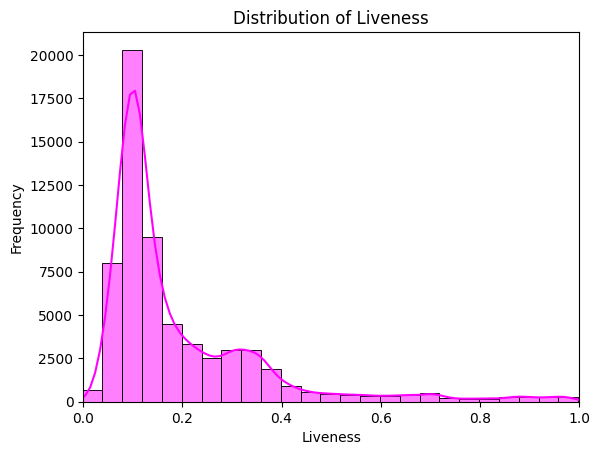

In [207]:
sns.histplot(data=spotify, x='liveness', kde=True, bins=50, color='magenta')
plt.title('Distribution of Liveness')
plt.xlabel('Liveness')
plt.ylabel('Frequency')
plt.xlim(0,1)
plt.show()

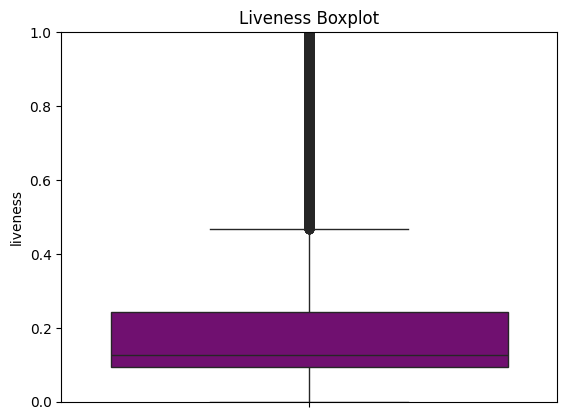

In [208]:
sns.boxplot(data=spotify, y='liveness', color='purple')
plt.title('Liveness Boxplot')
plt.ylim(0,1)
plt.show()

In [209]:
def liveness_type(val):
    if val < 0.2:
        return 'Studio'
    elif val < 0.8:
        return 'Slightly Live'
    else:
        return 'Live'

spotify['liveness_type'] = spotify['liveness'].apply(liveness_type)

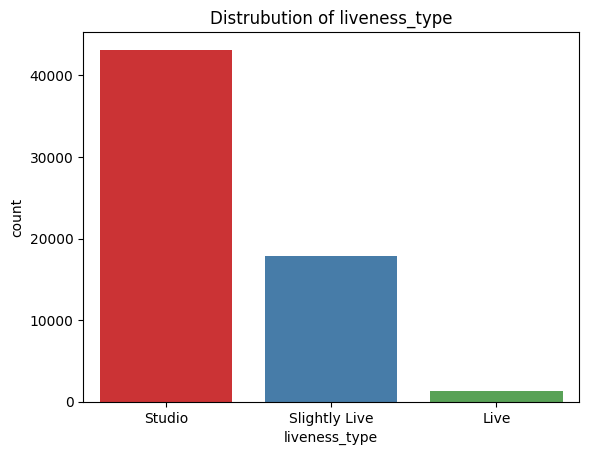

In [210]:
sns.countplot(x='liveness_type', data=spotify, palette='Set1')
plt.title('Distrubution of liveness_type')
plt.show()

loundness

In [211]:
spotify['loudness'].describe()

,loudness
count,62317.000000
mean,-65.103433
std,2369.051478
min,-100000.000000
25%,-10.727000
50%,-7.506000
75%,-5.456000
max,1.233000


In [212]:
spotify['loudness'] = spotify['loudness'].replace(-100000.0, -60.0)

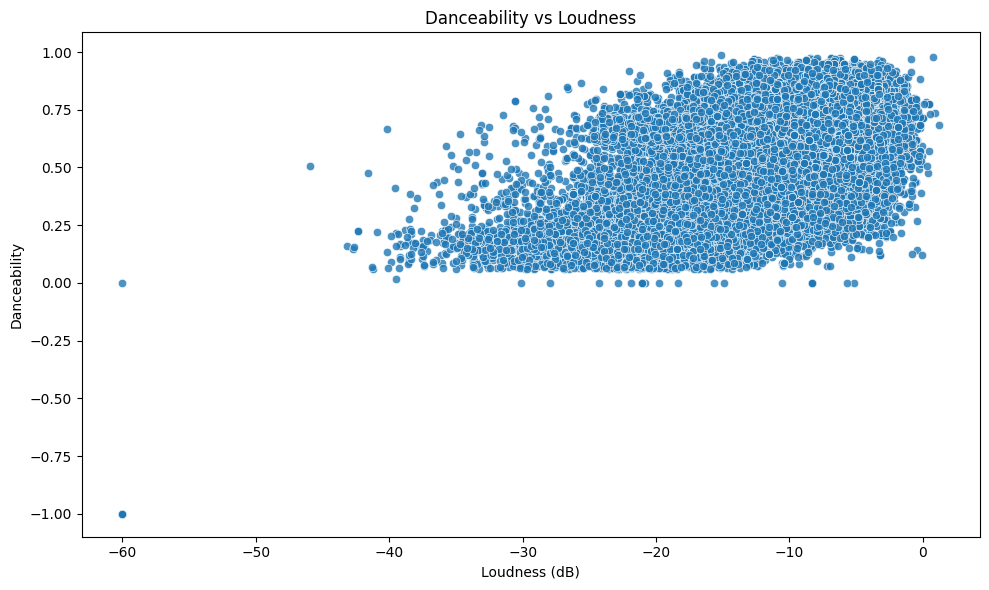

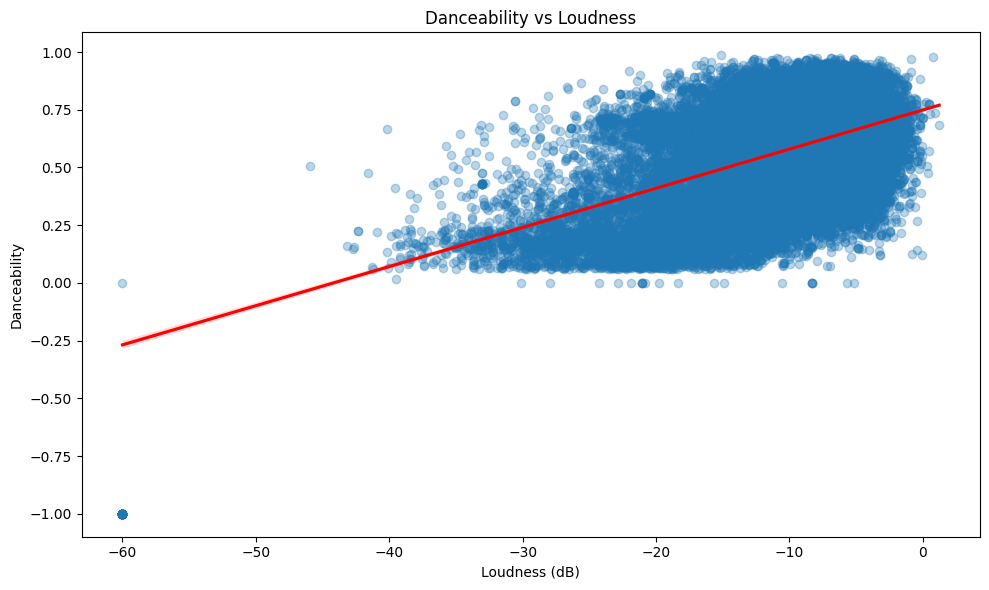

In [213]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=spotify, x='loudness', y='danceability', alpha=0.8)

plt.title('Danceability vs Loudness')
plt.xlabel('Loudness (dB)')
plt.ylabel('Danceability')
plt.grid(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(data=spotify, x='loudness', y='danceability', scatter_kws={'alpha':0.3}, line_kws={'color': 'red'})
plt.title('Danceability vs Loudness')
plt.xlabel('Loudness (dB)')
plt.ylabel('Danceability')
plt.grid(False)
plt.tight_layout()
plt.show()

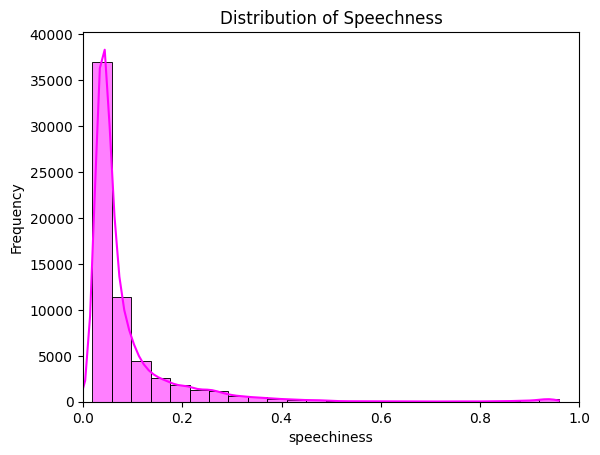

In [214]:
sns.histplot(data=spotify, x='speechiness', kde=True, bins=50, color='magenta')
plt.title('Distribution of Speechness')
plt.xlabel('speechiness')
plt.ylabel('Frequency')
plt.xlim(0,1)
plt.show()

In [215]:
def classify_speechiness(s):
    if s <= 0.03:
        return 'Instrumental'
    elif s <= 0.10:
        return 'Pop / Melodic'
    elif s <= 0.50:
        return 'Rap / Spoken Verse'
    elif s > 0.66:
        return 'Speech / Podcast'
    else:
        return 'Other / Mixed'
df['speech_type'] = df['speechiness'].apply(classify_speechiness)

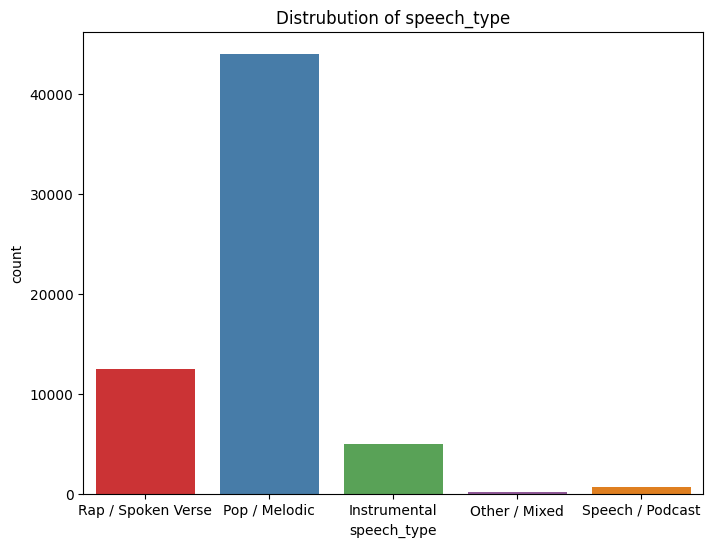

In [216]:
plt.figure(figsize=(8, 6))
sns.countplot(x='speech_type', data=df, palette='Set1')
plt.title('Distrubution of speech_type')
plt.show()

In [217]:
df2 = df.groupby(['year', 'speech_type']).size().reset_index(name='count')

In [218]:
df2.head(5)

,year,speech_type,count
0,1971,Pop / Melodic,11
1,1971,Rap / Spoken Verse,1
2,1972,Instrumental,5
3,1972,Pop / Melodic,16
4,1973,Instrumental,16


In [221]:
df['language'].value_counts()

,count
language,
English,23392
Unknown,13005
Tamil,12681
Korean,6893
Hindi,5740
Telugu,324
Malayalam,282


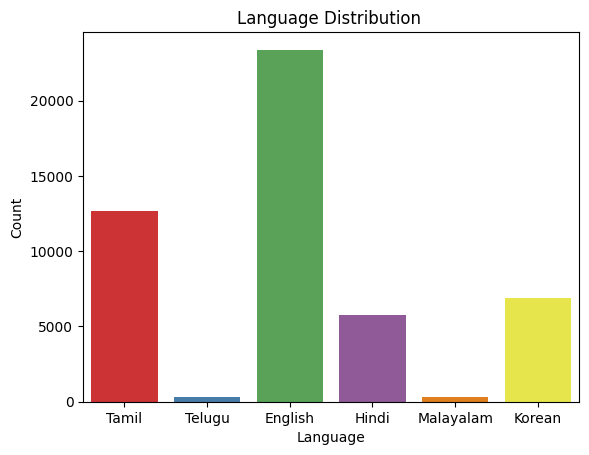

In [222]:
df_filtered = df[df['language'] != 'Unknown']

sns.countplot(x=df_filtered['language'], palette='Set1')
plt.title('Language Distribution ')
plt.xlabel('Language')
plt.ylabel('Count')
plt.show()

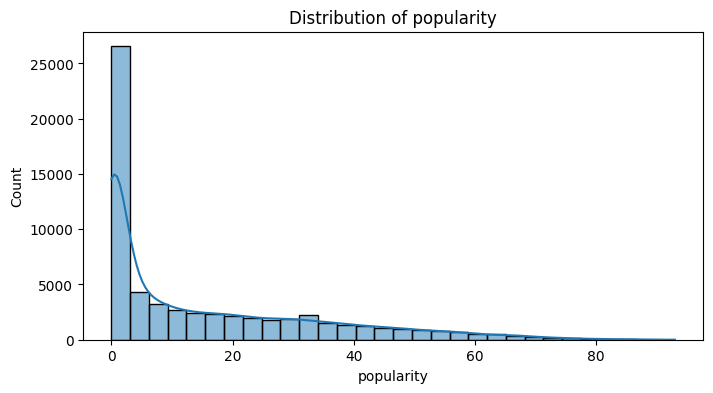

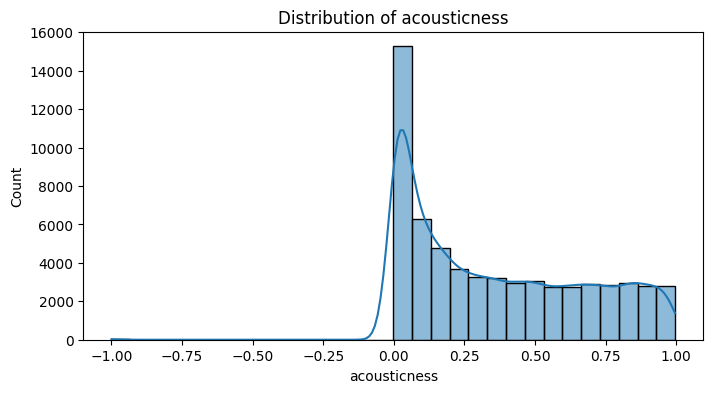

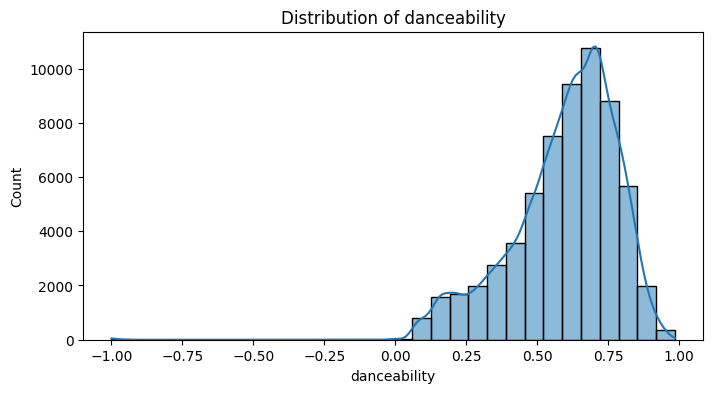

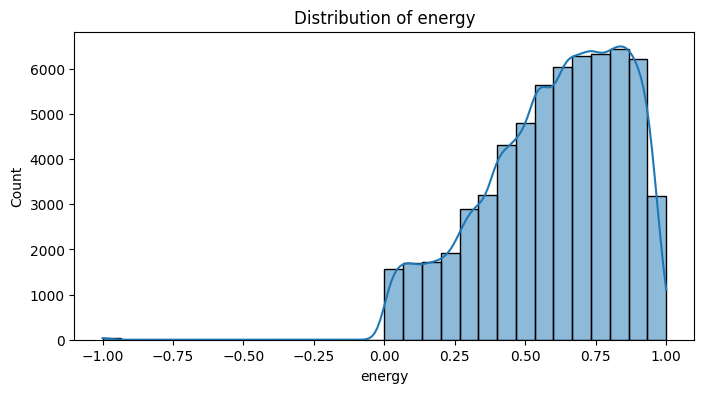

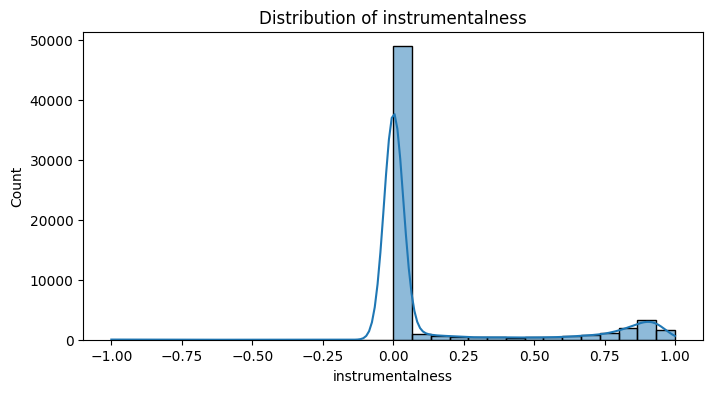

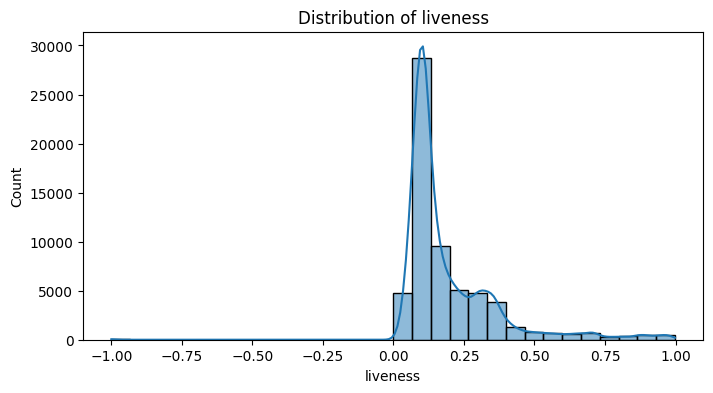

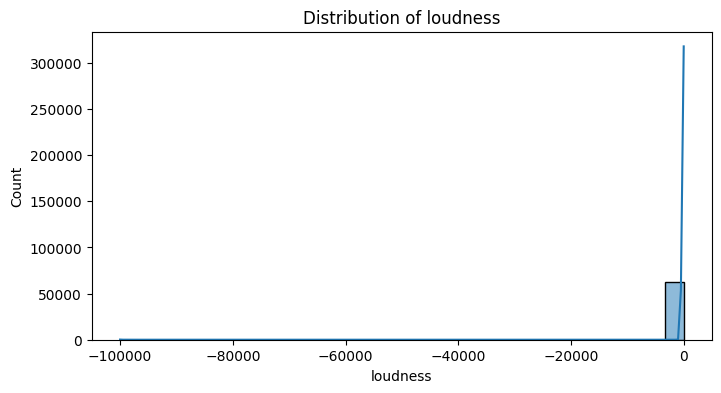

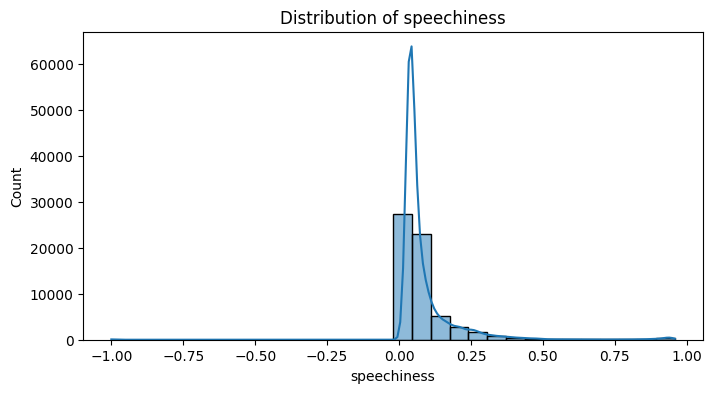

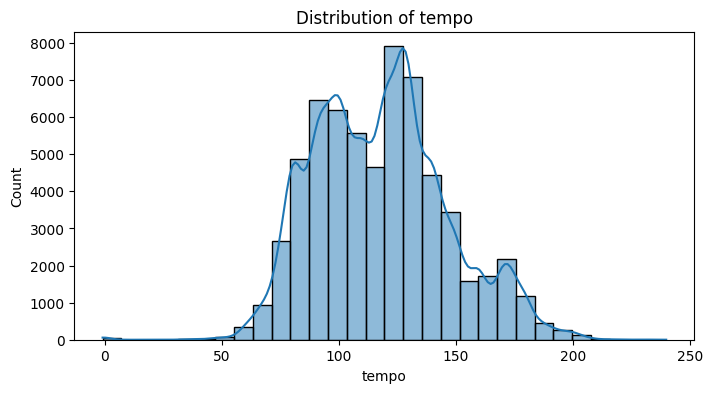

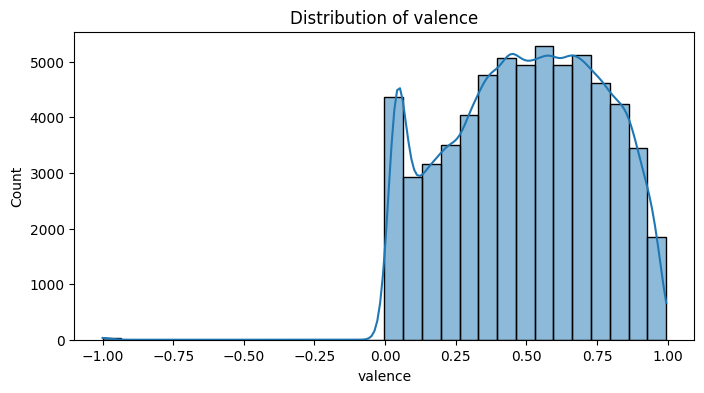

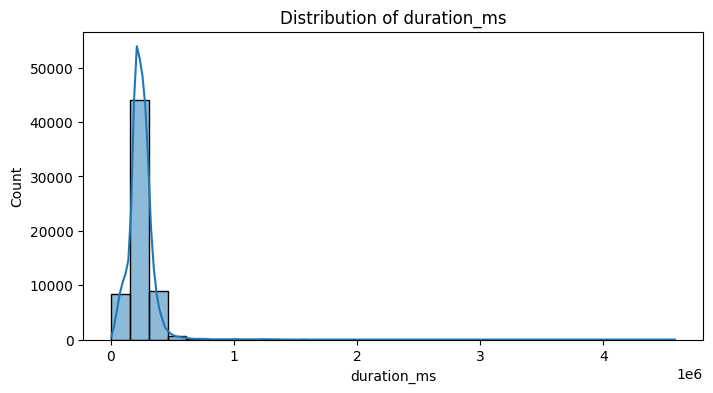

In [224]:
num_cols = ['popularity','acousticness','danceability','energy',
            'instrumentalness','liveness','loudness','speechiness',
            'tempo','valence','duration_ms']

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

Bi-variate

N vs N

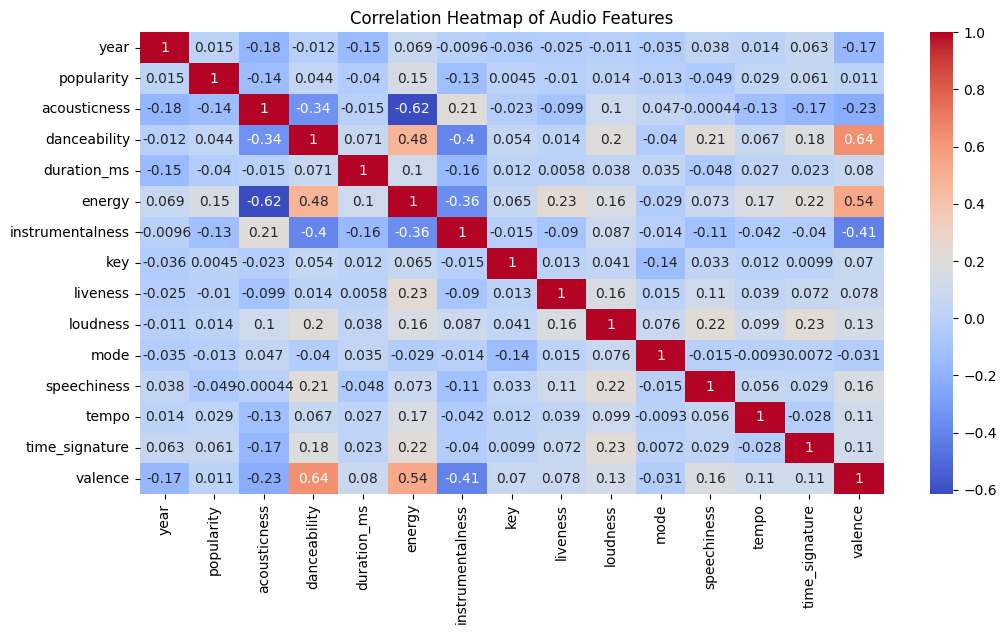

In [234]:
# Correlation heatmap
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Audio Features")
plt.show()

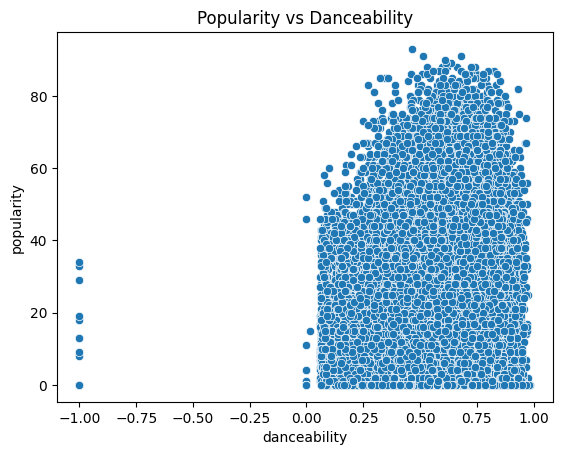

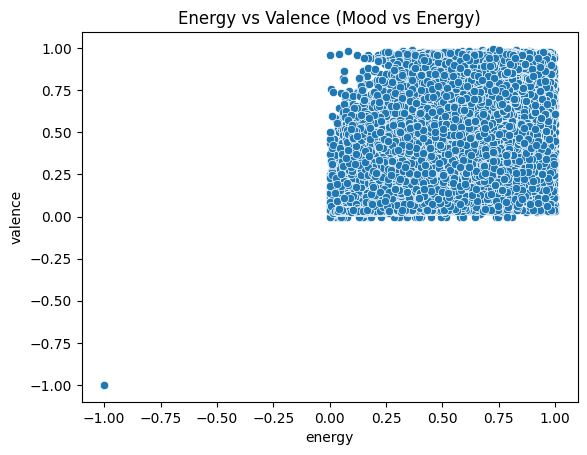

In [235]:
# Scatter: Popularity vs Danceability
sns.scatterplot(x='danceability', y='popularity', data=df)
plt.title("Popularity vs Danceability")
plt.show()

# Scatter: Energy vs Valence
sns.scatterplot(x='energy', y='valence', data=df)
plt.title("Energy vs Valence (Mood vs Energy)")
plt.show()


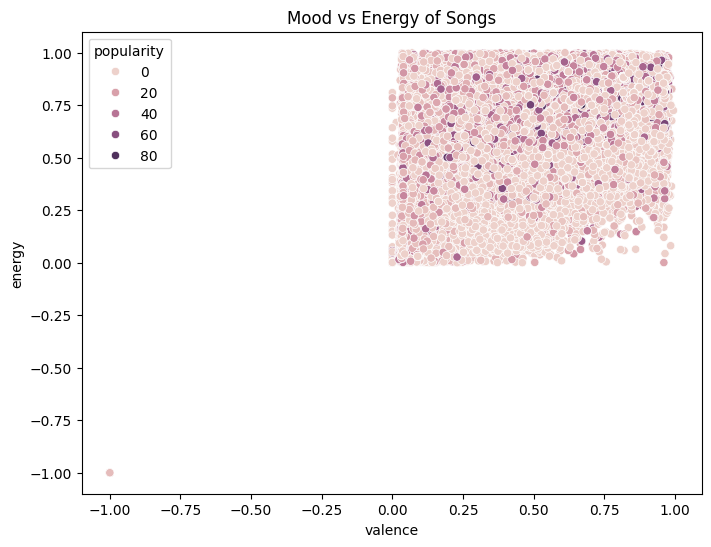

In [236]:
# Valence vs Energy scatter
plt.figure(figsize=(8,6))
sns.scatterplot(x="valence", y="energy", hue="popularity", data=df)
plt.title("Mood vs Energy of Songs")
plt.show()

Multivariate

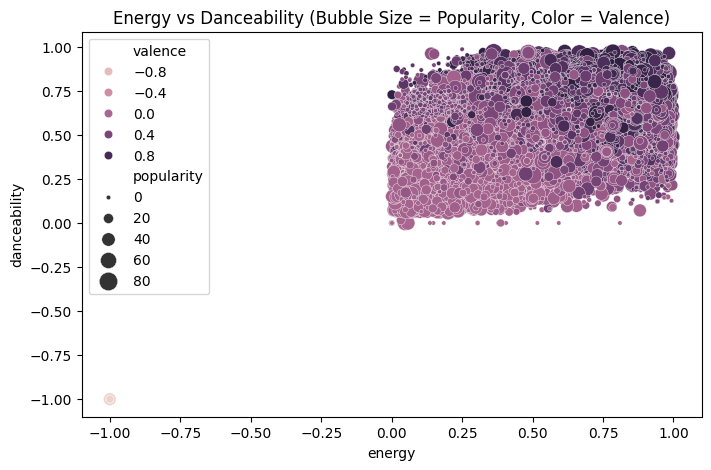

In [230]:
# Energy, Danceability & Popularity together
plt.figure(figsize=(8,5))
sns.scatterplot(x='energy', y='danceability', size='popularity', hue='valence', data=df, sizes=(10,200))
plt.title("Energy vs Danceability (Bubble Size = Popularity, Color = Valence)")
plt.show()

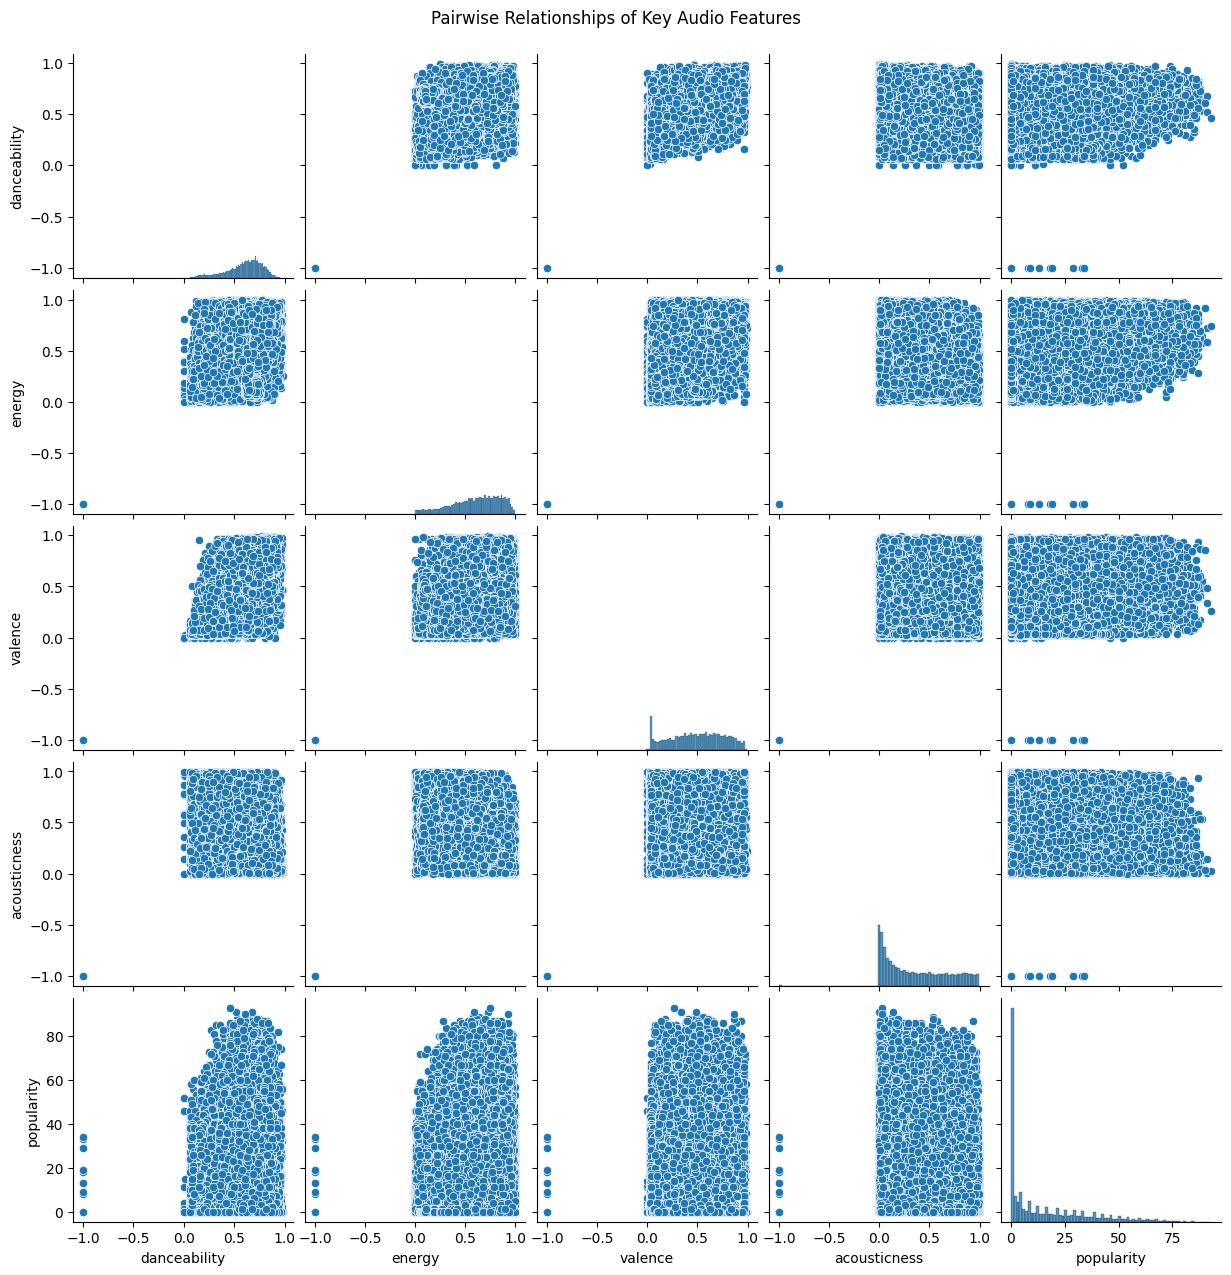

In [228]:
# Pairplot for main audio features
sns.pairplot(df[['danceability','energy','valence','acousticness','popularity']])
plt.suptitle("Pairwise Relationships of Key Audio Features", y=1.02)
plt.show()

Danceability, Energy, Valence by Language

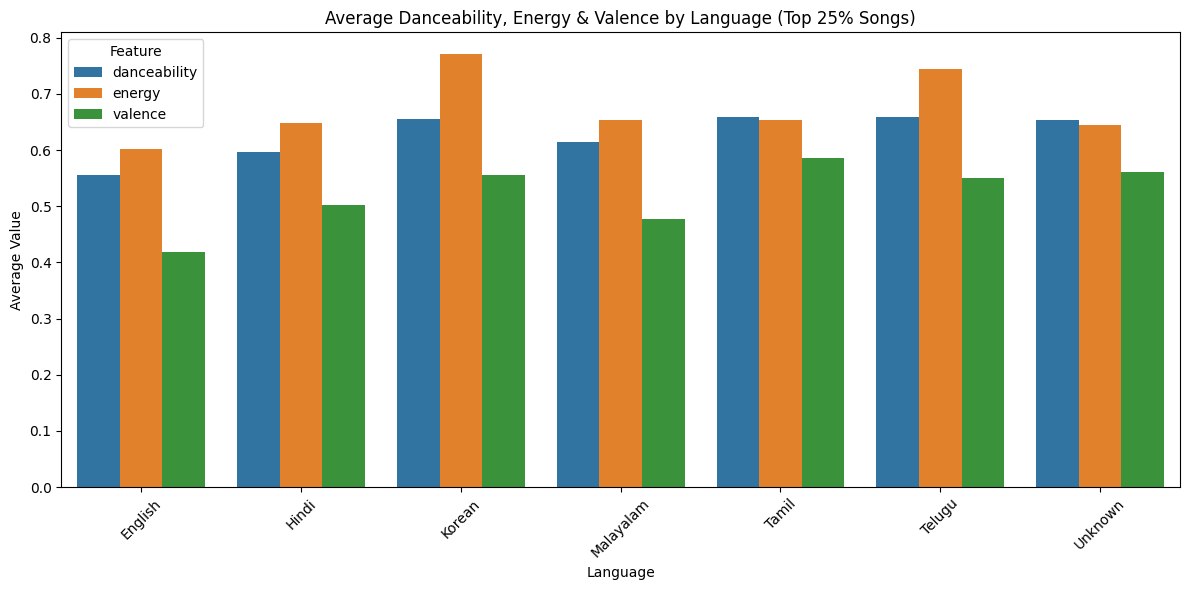

In [229]:
top_25 = df[df['popularity'] >= df['popularity'].quantile(0.75)]

# Group by language and find mean values of key features
lang_group = top_25.groupby('language')[['danceability', 'energy', 'valence']].mean().reset_index()

# Reshape data for plotting
lang_melted = lang_group.melt(id_vars='language', var_name='Feature', value_name='Average Value')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=lang_melted, x='language', y='Average Value', hue='Feature')
plt.title("Average Danceability, Energy & Valence by Language (Top 25% Songs)")
plt.xlabel("Language")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(title="Feature")
plt.tight_layout()
plt.show()

Time Series

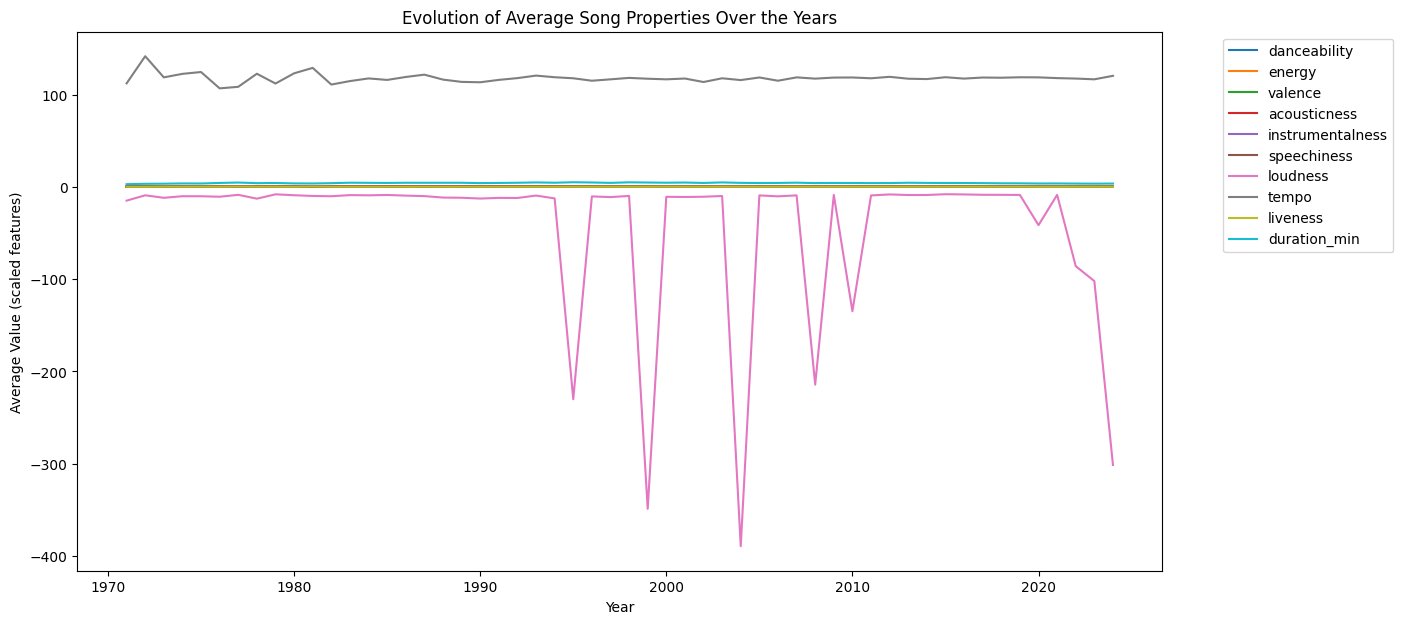

In [232]:
audio_features = [
    'danceability','energy','valence','acousticness',
    'instrumentalness','speechiness','loudness','tempo','liveness','duration_ms'
]

# Remove rows with missing year or audio features
df_year = df.dropna(subset=['year'] + audio_features)

# Group by year and take mean of each feature
yearly_trends = df_year.groupby('year')[audio_features].mean().reset_index()

# Convert duration from ms to minutes
yearly_trends['duration_min'] = yearly_trends['duration_ms'] / 60000
yearly_trends.drop(columns='duration_ms', inplace=True)

# Melt data for multi-feature line plot
trend_melted = yearly_trends.melt(id_vars='year', var_name='Feature', value_name='Average')

# Plot
plt.figure(figsize=(14,7))
sns.lineplot(x='year', y='Average', hue='Feature', data=trend_melted)
plt.title("Evolution of Average Song Properties Over the Years")
plt.xlabel("Year")
plt.ylabel("Average Value (scaled features)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

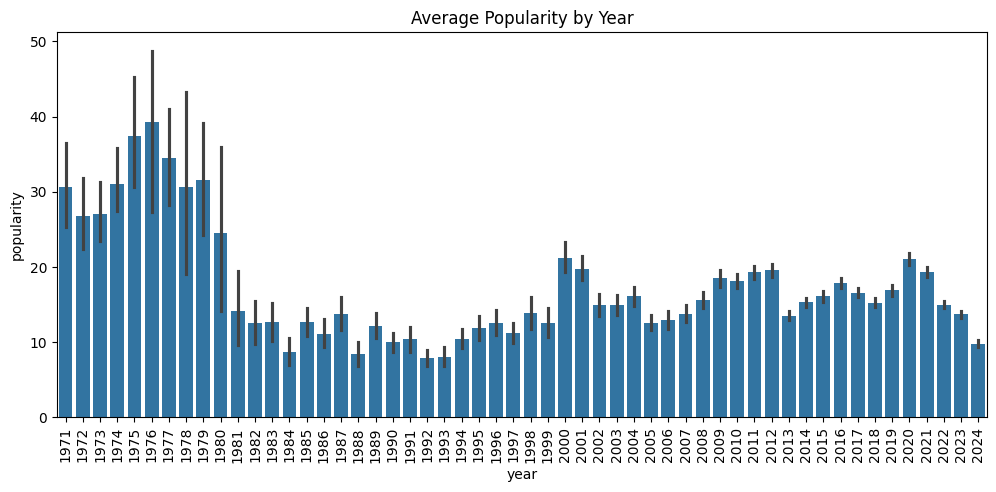

In [226]:
# Popularity by Year
plt.figure(figsize=(12,5))
sns.barplot(x='year', y='popularity', data=df, estimator='mean')
plt.title("Average Popularity by Year")
plt.xticks(rotation=90)
plt.show()


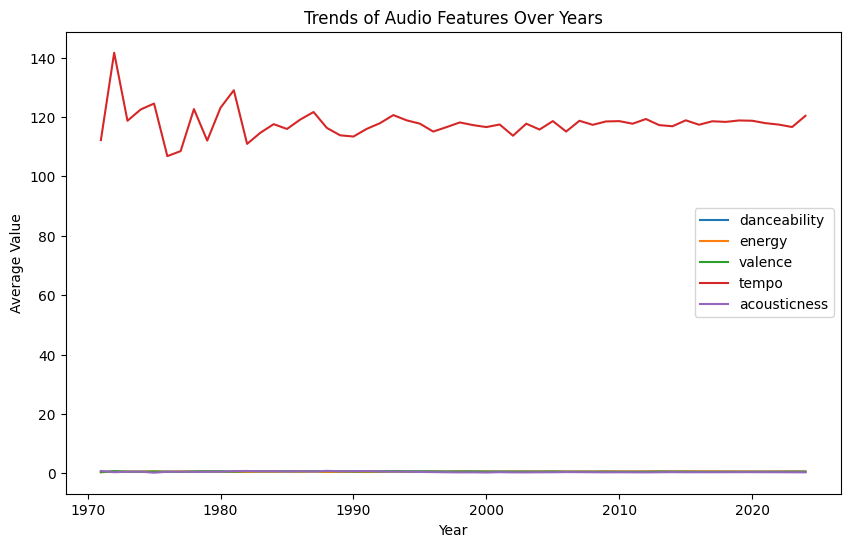

In [227]:
features = ['danceability','energy','valence','tempo','acousticness']
df_year = df.groupby('year')[features].mean().reset_index()

plt.figure(figsize=(10,6))
for col in features:
    plt.plot(df_year['year'], df_year[col], label=col)
plt.title("Trends of Audio Features Over Years")
plt.xlabel("Year")
plt.ylabel("Average Value")
plt.legend()
plt.show()

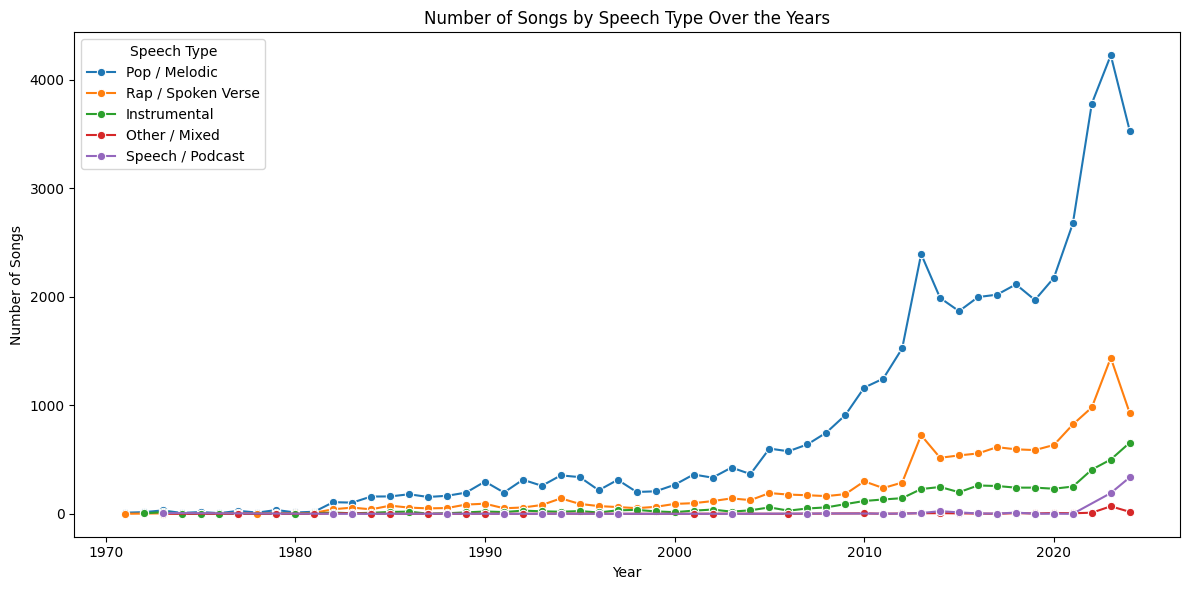

In [219]:

plt.figure(figsize=(12, 6))
sns.lineplot(data=df2, x='year', y='count', hue='speech_type', marker='o')

plt.title('Number of Songs by Speech Type Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Songs')
plt.legend(title='Speech Type')
plt.grid(False)
plt.tight_layout()
plt.show()


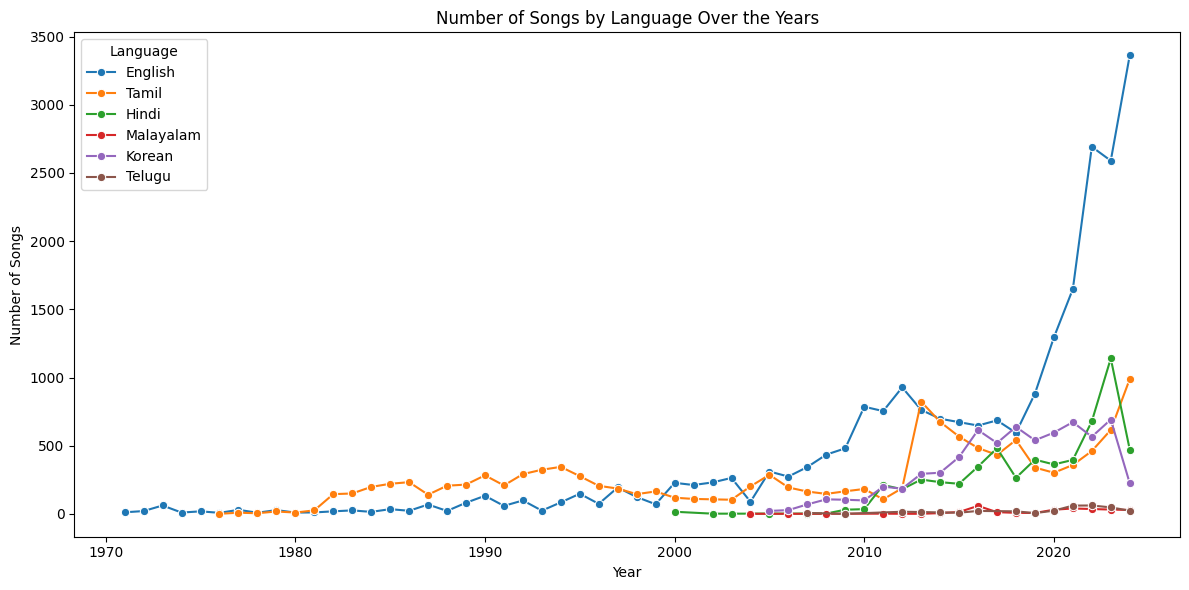

In [223]:
df3 = df_filtered.groupby(['year', 'language']).size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df3, x='year', y='count', hue='language', marker='o')

plt.title('Number of Songs by Language Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Songs')
plt.legend(title='Language')
plt.grid(False)
plt.tight_layout()
plt.show()

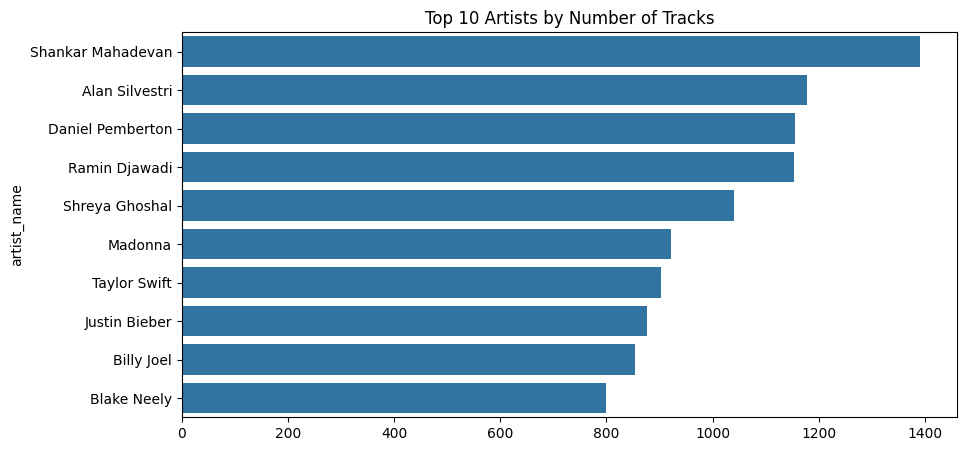

In [233]:

# Top 10 artists
top_artists = df['artist_name'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_artists.values, y=top_artists.index)
plt.title("Top 10 Artists by Number of Tracks")
plt.show()


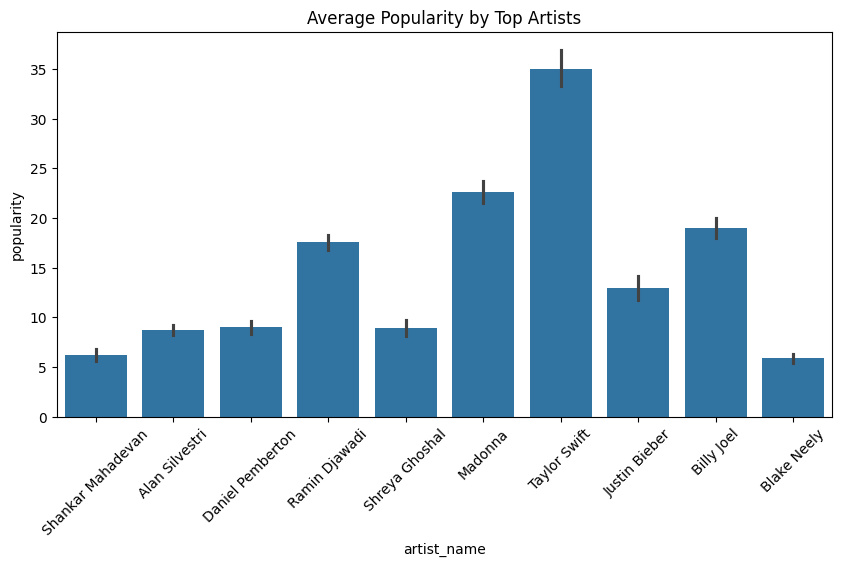

In [231]:
# Average popularity by top 10 artists
top_artists = df['artist_name'].value_counts().head(10).index
df_top = df[df['artist_name'].isin(top_artists)]

plt.figure(figsize=(10,5))
sns.barplot(x='artist_name', y='popularity', data=df_top, estimator='mean', order=top_artists)
plt.title("Average Popularity by Top Artists")
plt.xticks(rotation=45)
plt.show()

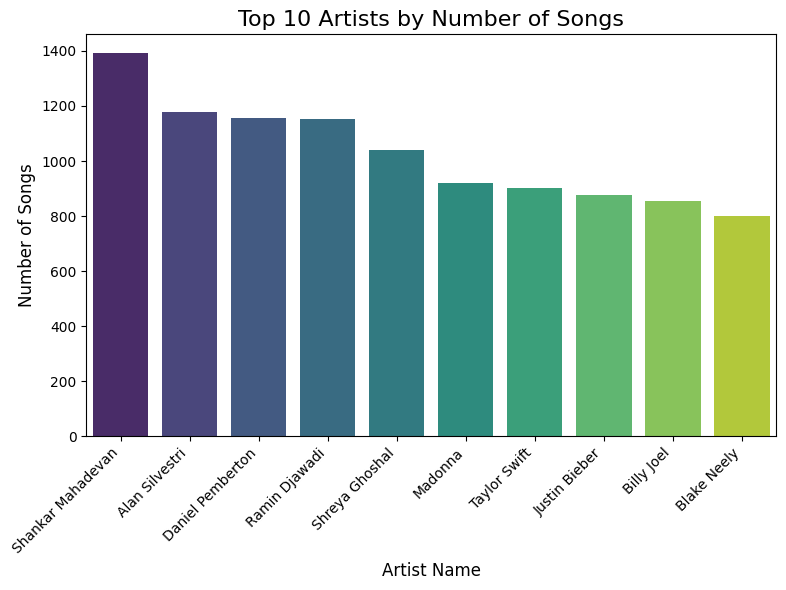

In [238]:
artist_counts = df['artist_name'].value_counts().head(10).reset_index()
artist_counts.columns = ['artist_name', 'song_count']

# Plot
plt.figure(figsize=(8,6))
sns.barplot(data=artist_counts, x='artist_name', y='song_count', palette="viridis")
plt.title("Top 10 Artists by Number of Songs", fontsize=16)
plt.xlabel("Artist Name", fontsize=12)
plt.ylabel("Number of Songs", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

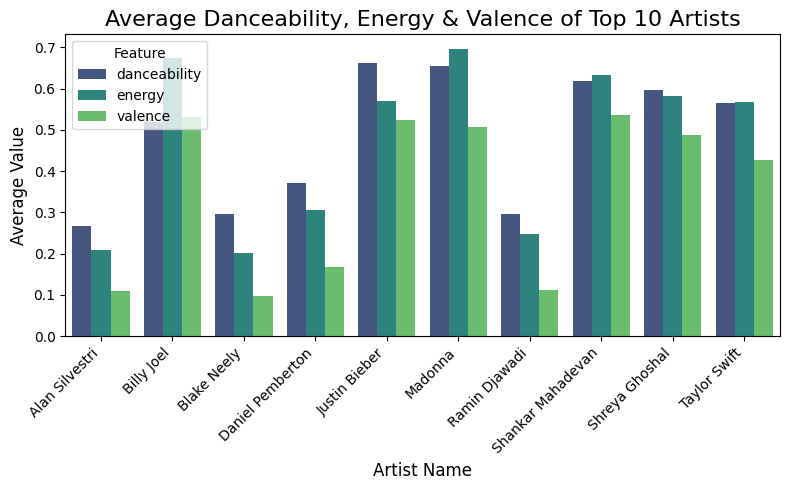

In [240]:
top_artists = df['artist_name'].value_counts().head(10).index

# Filter dataset for only these artists
df_top_artists = df[df['artist_name'].isin(top_artists)]

# Calculate average danceability, energy, valence for each artist
artist_features = df_top_artists.groupby('artist_name')[['danceability', 'energy', 'valence']].mean().reset_index()

# Melt data for grouped bar chart
artist_melted = artist_features.melt(id_vars='artist_name', var_name='Feature', value_name='Average')

# Plot grouped bar chart
plt.figure(figsize=(8,5))
sns.barplot(data=artist_melted, x='artist_name', y='Average', hue='Feature', palette="viridis")
plt.title("Average Danceability, Energy & Valence of Top 10 Artists", fontsize=16)
plt.xlabel("Artist Name", fontsize=12)
plt.ylabel("Average Value", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Feature")
plt.tight_layout()
plt.show()